# Phase 8 — Uplift Modeling (Synthetic Data)
**InterveneAI · T-learner for incremental intervention response.**

Goal: predict *who benefits incrementally* from an intervention — not who
buys. A customer with high P(buy | no intervention) is a sure thing:
treating them spends budget for zero incremental gain. The T-learner
estimates P(Y=1 | X, T=1) and P(Y=1 | X, T=0) with two classifiers and
scores uplift = treated_prob − control_prob. No uplift package is installed
here, so the approach is implemented transparently on scikit-learn.
Everything below uses synthetic outcomes only — no Olist causal claims.
Primary arm: coupon vs control; other arms reported for completeness. No
budget optimization is performed in this phase.

## Concepts
- **Uplift vs purchase probability.** Purchase probability P(Y=1 | X) mixes
  sure things (buy anyway), persuadables (buy iff treated), lost causes and
  do-not-disturb customers. Only persuadables repay targeting, and only the
  *difference* between the two potential outcomes identifies them.
- **T-learner.** Fit one classifier on treated rows, one on control rows;
  uplift(X) = P̂(Y=1 | X, T=1) − P̂(Y=1 | X, T=0). Simple and interpretable;
  its weakness (shown below) is that each model optimizes purchase
  prediction, not the difference — with rare outcomes both models learn
  nearly the same ranking and the difference is mostly noise.
- **Qini / AUUC.** Rank test rows by predicted uplift (descending); the Qini
  curve cumulates incremental gains over the top-k. Area under it (AUUC)
  beats random targeting iff the ranking finds persuadables first. The
  oracle ranking (true_cate) bounds what is achievable; the Qini coefficient
  scales model gain between random (0) and oracle (1).

In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = None
for cand in [Path("data/synthetic/intervention_experiment.parquet"),
             Path("../data/synthetic/intervention_experiment.parquet")]:
    if cand.exists():
        ROOT = cand.resolve().parents[2]
        break
assert ROOT is not None, "synthetic data not found"
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

def find(base):
    p = ROOT / base
    assert p.exists(), p
    return p

import joblib
from src.causal.uplift_model import (
    ARM_NAMES, FEATURES, TEST_START, TRAIN_END, auuc, load_uplift_frame,
    predict_uplift, qini_curve)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

df = load_uplift_frame()
with open(find("models/uplift_metrics.json")) as f:
    saved = json.load(f)
bundle = joblib.load(find("models/uplift_tlearner.pkl"))
pipe_t, pipe_c = bundle["treated_pipeline"], bundle["control_pipeline"]
print("primary arm:", bundle["arm_name"], "| train to", saved["train_end"],
      "| test from", saved["test_start"])
test = df[df["snapshot_date"] >= TEST_START]
sub = test[test["intervention_type"].isin((0, 1))].copy()
sub["uplift"] = predict_uplift(pipe_t, pipe_c, sub[FEATURES])
sub["p_control"] = pipe_c.predict_proba(sub[FEATURES])[:, 1]
print("test coupon+control rows:", len(sub))

primary arm: coupon | train to 2017-12-01 | test from 2018-04-01
test coupon+control rows: 68825


## 1. Verify saved uplift metrics by recomputation
AUUC and the uplift–oracle rank correlation are recomputed from the saved
pipelines and asserted against the JSON before any interpretation.

In [2]:
y = sub["outcome"].to_numpy()
t = (sub["intervention_type"] == 1).astype(int).to_numpy()
u = sub["uplift"].to_numpy()
xs, qm = qini_curve(y, t, u)
got_auuc = auuc(xs, qm)
exp_auuc = saved["arms"]["1"]["auuc_model"]
assert abs(got_auuc - exp_auuc) < 1e-9, (got_auuc, exp_auuc)
got_sp = float(pd.Series(u).corr(pd.Series(sub["true_cate"].to_numpy()),
                                 method="spearman"))
assert abs(got_sp - saved["arms"]["1"]["spearman_vs_oracle"]) < 1e-9
print("AUUC coupon:", round(got_auuc, 2), "| saved:", round(exp_auuc, 2), "| match")
print("spearman(uplift, oracle):", round(got_sp, 3), "| verified")
print("predicted uplift range: pp",
      round(100 * u.min(), 1), "to", round(100 * u.max(), 1),
      "(magnitudes vs §3 observed diffs ~1pp: severely miscalibrated)")

AUUC coupon: 108.95 | saved: 108.95 | match
spearman(uplift, oracle): -0.005 | verified
predicted uplift range: pp -48.2 to 54.7 (magnitudes vs §3 observed diffs ~1pp: severely miscalibrated)


## 2. Qini curves — model vs random vs oracle
If the T-learner ranks persuadables first, its curve rises above the random
diagonal toward the oracle. All three arms shown; coupon is primary.

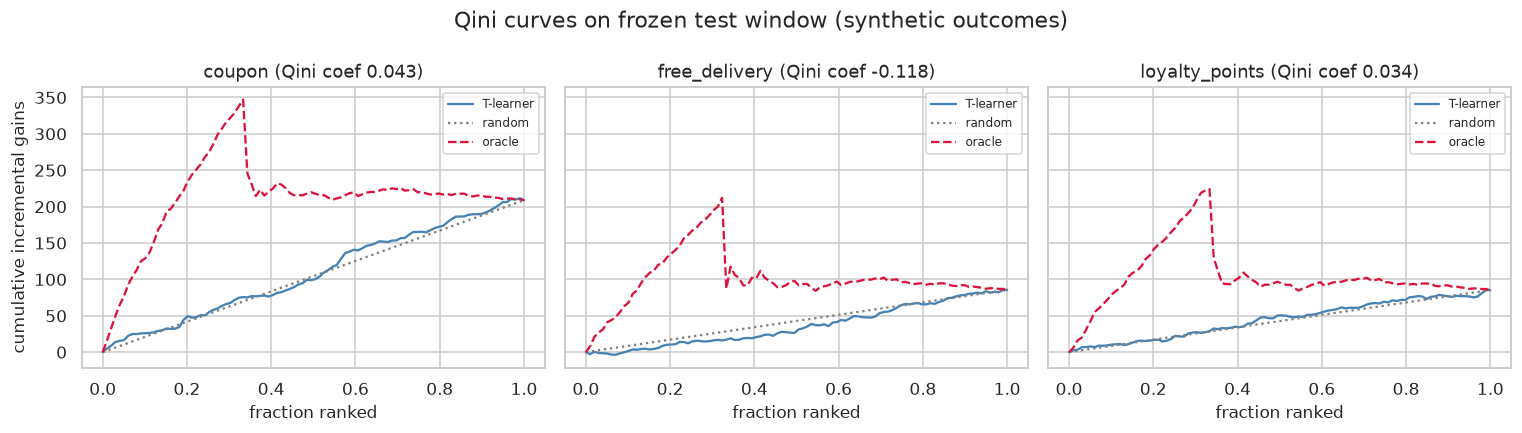

Qini coefficients: {'coupon': 0.043, 'free_delivery': -0.118, 'loyalty_points': 0.034}


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, arm in zip(axes, ["1", "2", "3"]):
    c = saved["arms"][arm]["qini_curve"]
    ax.plot(c["xs"], c["model"], color="steelblue", label="T-learner")
    ax.plot(c["xs"], c["random"], color="grey", linestyle=":",
            label="random")
    ax.plot(c["xs"], c["oracle"], color="crimson", linestyle="--",
            label="oracle")
    ax.set_title(saved["arms"][arm]["name"] +
                 " (Qini coef " +
                 str(round(saved["arms"][arm]["qini_coefficient"], 3)) + ")")
    ax.set_xlabel("fraction ranked")
    ax.legend(fontsize=8)
axes[0].set_ylabel("cumulative incremental gains")
plt.suptitle("Qini curves on frozen test window (synthetic outcomes)")
plt.tight_layout()
plt.show()
print("Qini coefficients:",
      {saved["arms"][a]["name"]: round(saved["arms"][a]["qini_coefficient"], 3)
       for a in ["1", "2", "3"]})

## 3. Uplift-by-decile calibration
Mean predicted uplift per decile against the observed treated-minus-control
rate (Newcombe CI). A useful ranker is monotone; magnitudes need not match
(the scores are uncalibrated), but direction must hold.

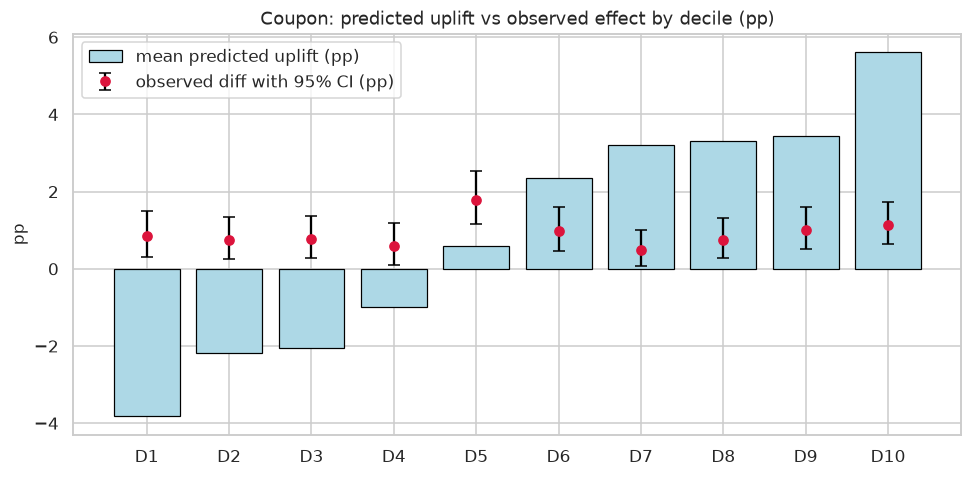

In [4]:
dec = pd.DataFrame(saved["arms"]["1"]["deciles"])
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(dec))
ax.bar(x, [100 * v for v in dec["mean_predicted_uplift"]], color="lightblue",
       edgecolor="black", linewidth=0.8, label="mean predicted uplift (pp)")
obs = [100 * v for v in dec["observed_diff"]]
lo = [100 * (v - l) for v, l in zip(dec["observed_diff"], dec["ci_lo"])]
hi = [100 * (h - v) for v, h in zip(dec["observed_diff"], dec["ci_hi"])]
ax.errorbar(x, obs, yerr=[lo, hi], fmt="o", color="crimson",
            ecolor="black", capsize=4, label="observed diff with 95% CI (pp)")
ax.set_xticks(x)
ax.set_xticklabels(["D" + str(i + 1) for i in x])
ax.set_title("Coupon: predicted uplift vs observed effect by decile (pp)")
ax.set_ylabel("pp")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Uplift segments
Negative predicted uplift (< 0), then tertiles of the rest. Each segment
shows the observed treated-minus-control difference and the oracle mean —
the segment view a targeting rule would actually use.

 segment     n  mean_predicted_uplift  observed_diff  oracle_mean
negative 24896              -0.025560       0.007180     0.002679
     low 14643               0.010953       0.013722     0.003720
  medium 14643               0.032381       0.007250     0.002634
    high 14643               0.044638       0.009547     0.002724


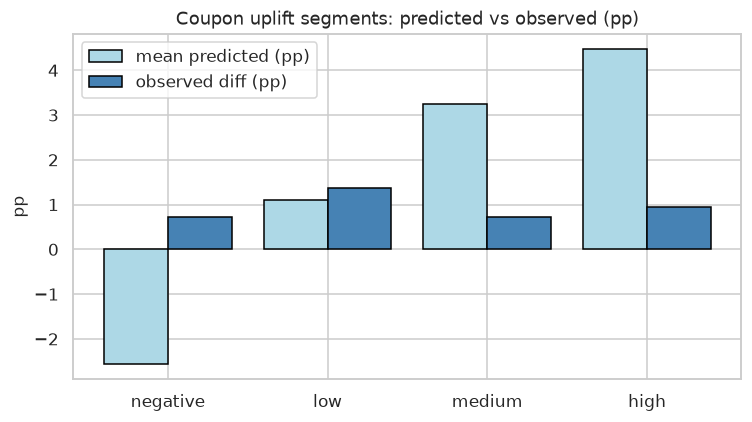

In [5]:
seg = pd.DataFrame(saved["arms"]["1"]["segments"])
print(seg.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(seg))
ax.bar(x - 0.2, [100 * v for v in seg["mean_predicted_uplift"]], 0.4,
       label="mean predicted (pp)", color="lightblue", edgecolor="black")
ax.bar(x + 0.2, [100 * v for v in seg["observed_diff"]], 0.4,
       label="observed diff (pp)", color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(seg["segment"])
ax.set_title("Coupon uplift segments: predicted vs observed (pp)")
ax.set_ylabel("pp")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Why normal classification is insufficient for targeting
Rank test rows by the control model's purchase probability P(Y=1 | X, T=0)
— the best "who buys" ranker available — and draw its Qini curve: the
incremental gains it captures. Overlap of its top-10% with the uplift
model's top-10% quantifies how different the two targeting rules are.

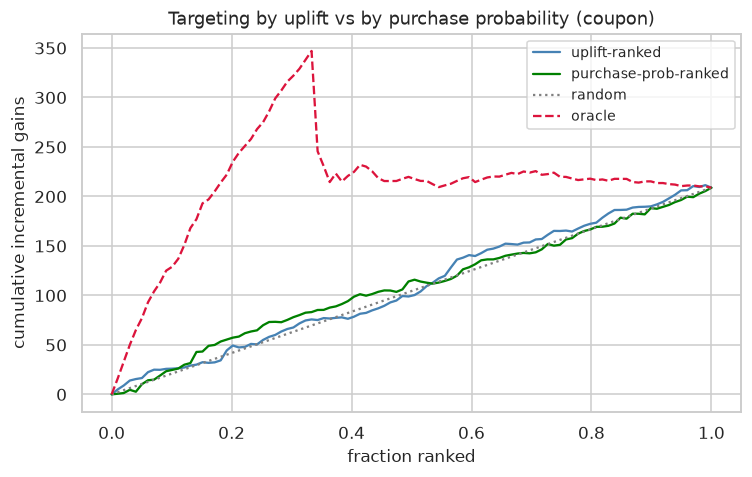

AUUC purchase-prob-ranked: 109.26 | uplift-ranked: 108.95 | random: 104.4
top-10% overlap (uplift vs purchase-prob): 0.3% of 6882 rows
mean control prob in uplift top-10%: 0.3827 | in purchase-prob top-10%: 0.5863


In [6]:
pc = sub["p_control"].to_numpy()
_, q_cls = qini_curve(y, t, pc)
xs0 = saved["arms"]["1"]["qini_curve"]["xs"]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs0, saved["arms"]["1"]["qini_curve"]["model"], color="steelblue",
        label="uplift-ranked")
ax.plot(xs0, q_cls, color="green", label="purchase-prob-ranked")
ax.plot(xs0, saved["arms"]["1"]["qini_curve"]["random"], color="grey",
        linestyle=":", label="random")
ax.plot(xs0, saved["arms"]["1"]["qini_curve"]["oracle"], color="crimson",
        linestyle="--", label="oracle")
ax.set_title("Targeting by uplift vs by purchase probability (coupon)")
ax.set_xlabel("fraction ranked")
ax.set_ylabel("cumulative incremental gains")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
auuc_cls = auuc(xs0, q_cls)
print("AUUC purchase-prob-ranked:", round(auuc_cls, 2),
      "| uplift-ranked:", round(saved["arms"]["1"]["auuc_model"], 2),
      "| random:", round(saved["arms"]["1"]["auuc_random"], 2))
k = int(0.10 * len(sub))
top_u = set(np.argsort(-u, kind="stable")[:k])
top_p = set(np.argsort(-pc, kind="stable")[:k])
print("top-10% overlap (uplift vs purchase-prob):",
      str(round(100 * len(top_u & top_p) / k, 1)) + "% of",
      str(k), "rows")
print("mean control prob in uplift top-10%:",
      round(float(sub.iloc[sorted(top_u)]["p_control"].mean()), 4),
      "| in purchase-prob top-10%:",
      round(float(sub.iloc[sorted(top_p)]["p_control"].mean()), 4))

## Key findings (synthetic data — no real-world targeting claims)

1. **The simple T-learner does not rank incremental benefit.** Qini
   coefficients are 0.043 (coupon), −0.118 (free_delivery), 0.034
   (loyalty) — at or below random targeting — and predicted uplift has
   zero rank correlation with the oracle (spearman −0.005). Decile
   observed diffs (0.5–1.8pp) show no monotone pattern across predicted
   deciles.
2. **Score magnitudes are unusable.** Predictions span −48pp to +55pp
   while all observed diffs are ~1pp: balanced class weights distort both
   arm models, so scores cannot be read as effect sizes — and here not
   even as ranks.
3. **Segments are score bins, not true effects.** The "negative" segment
   (24,896 rows, mean predicted −2.6pp) still shows a +0.72% observed
   difference; high (0.96%) does not beat low (1.37%). No segment credibly
   isolates persuadables or do-not-disturb customers.
4. **Classification targeting fails differently, not better.** Ranking by
   purchase probability captures no more incremental gain (AUUC 109.3 vs
   uplift-ranked 109.0 vs random 104.4) — yet its top-10% overlaps the
   uplift top-10% by only 0.3%, with far higher control probabilities
   (0.59 vs 0.38). The rules target different kinds of customers
   (sure-things vs noise), which is exactly why "who buys" can never
   substitute for "who benefits" — even though neither rule works here.
5. **Why it fails here.** Base rates ~1% with weak linear features: both
   arm models learn nearly the same purchase ranking, and their difference
   is dominated by noise. Each model optimizes purchase prediction, never
   the contrast. This argues for contrast-aware approaches later — not
   implemented in this phase.
6. **No budget use.** With uncalibrated scores and random-equivalent
   ranking, no cost-based targeting rule is derived; optimization is
   explicitly deferred.


## Limitations and non-goals
- The T-learner difference inherits both models' errors; with ~1% base
  rates and weak features it ranks no better than random here — a finding
  about this simple approach, not proof uplift is unpredictable.
- Predicted magnitudes (−48pp to +55pp) are unusable as effect sizes
  (balanced weights distort both arm models); only ranks were evaluated.
- Segments and deciles describe the test window; CIs reflect sampling
  noise, not model uncertainty. Costs and budget-constrained rules are
  deferred to the optimization phase, not designed here.